在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5999225 entries, 0 to 5999224
Data columns (total 21 columns):
 #   Column      Dtype  
---  ------      -----  
 0   flt_no      object 
 1   bd_type     object 
 2   cap         float64
 3   aircraft    object 
 4   legs        int64  
 5   leg_no      int64  
 6   duration    float64
 7   pax         int64  
 8   a           object 
 9   b           object 
 10  c           object 
 11  year        int64  
 12  month       int64  
 13  day         int64  
 14  weekday     int64  
 15  hour        int64  
 16  minute      int64  
 17  second      int64  
 18  from        object 
 19  to          object 
 20  unit_price  float64
dtypes: float64(3), int64(10), object(8)
memory usage: 961.2+ MB
None


## 生成加权图

每对城市间的总客流量：
从 KNqX4/Q5Noc= 到 HexFWXqbb8I= 的航班客流量总和: 4169
从 KNqX4/Q5Noc= 到 iX2Pe2pxiqQ= 的航班客流量总和: 17787
从 KNqX4/Q5Noc= 到 tKjndGSl9NQ= 的航班客流量总和: 177299
从 KNqX4/Q5Noc= 到 /qxKZMQeBus= 的航班客流量总和: 100713
从 KNqX4/Q5Noc= 到 zwVGiYamVc0= 的航班客流量总和: 39090
从 KNqX4/Q5Noc= 到 h9GisD/ZayE= 的航班客流量总和: 49632
从 KNqX4/Q5Noc= 到 Qe7TEMbQt6o= 的航班客流量总和: 49835
从 KNqX4/Q5Noc= 到 OJ0BsQ7KlKk= 的航班客流量总和: 51273
从 KNqX4/Q5Noc= 到 XUXDuFGVfBM= 的航班客流量总和: 55780
从 KNqX4/Q5Noc= 到 vbo2dwBOeps= 的航班客流量总和: 359736
从 KNqX4/Q5Noc= 到 QyEgIt0M8Sg= 的航班客流量总和: 20436
从 KNqX4/Q5Noc= 到 N74XPg/TTtg= 的航班客流量总和: 30318
从 KNqX4/Q5Noc= 到 /M8gHzjxpNU= 的航班客流量总和: 279934
从 KNqX4/Q5Noc= 到 y+pJ91YLvhA= 的航班客流量总和: 132118
从 KNqX4/Q5Noc= 到 Eg2bemFsI9I= 的航班客流量总和: 21762
从 KNqX4/Q5Noc= 到 fl/vmiIcdls= 的航班客流量总和: 38401
从 KNqX4/Q5Noc= 到 EF4D0LqfA8Q= 的航班客流量总和: 25283
从 KNqX4/Q5Noc= 到 AlGb30xUGAU= 的航班客流量总和: 72289
从 KNqX4/Q5Noc= 到 uwQNil0XG60= 的航班客流量总和: 9581
从 KNqX4/Q5Noc= 到 0J4jz5aCatU= 的航班客流量总和: 207225
从 KNqX4/Q5Noc= 到 1/9nd1jNCE0= 的航班客流量总和: 31058
从 KNqX4/Q5Noc= 到 g

/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/

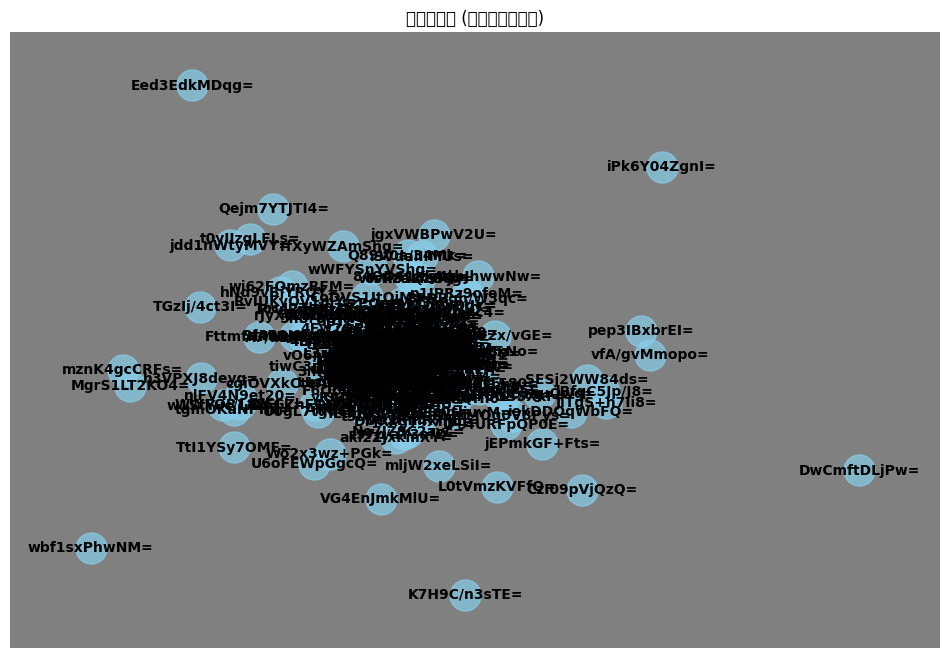

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 2. 创建空图
G = nx.Graph()

# 3. 遍历每一行，获取 'from', 'to' 和 'pax' 数据
for index, row in data.iterrows():
    city_from = row['from']
    city_to = row['to']
    pax = row['pax']
    
    # 如果从城市到目标城市的边已经存在，更新边的权重（累加 pax），否则添加边
    if G.has_edge(city_from, city_to):
        G[city_from][city_to]['weight'] += pax
    else:
        G.add_edge(city_from, city_to, weight=pax)

# 4. 打印城市间的总客流量
print("每对城市间的总客流量：")
for edge in G.edges(data=True):
    print(f"从 {edge[0]} 到 {edge[1]} 的航班客流量总和: {edge[2]['weight']}")

## 创建并训练 DeepWalk 模型

In [3]:
import networkx as nx
from node2vec import Node2Vec

1. 加载图并准备数据

In [4]:
# 通过 node2vec 包生成随机游走
node2vec = Node2Vec(G, dimensions=64, walk_length=3, num_walks=2000, workers=4, weight_key='weight')

# 训练模型
model = node2vec.fit(window=3, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/252 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 500/500 [00:01<00:00, 396.95it/s]


2. 获取节点的嵌入向量

In [5]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.16990833 -0.36589098  0.3378528   0.2635176  -0.0732797  -0.38230765
 -0.213105   -0.2617996  -0.1947697  -0.21024631  0.4208515  -0.06630554
  0.46032327  0.4124183   0.2146863   0.36699507 -0.28113675 -0.23705487
 -0.64795154  0.15966955  0.12301788 -0.15191682  0.3913412  -0.00428641
 -0.22690506  0.10324526  0.07923089  0.1395517   0.35013363  0.25576773
 -0.46405503  0.25738397 -0.35379592 -0.19583777  0.3477297  -0.08044196
 -0.24469951  0.06394117  0.37687367  0.12734109  0.20323601  0.56693447
  0.06400139 -0.07538351 -0.2839362  -0.21570759 -0.5525135  -0.17048466
 -0.03900976  0.37177208 -0.3580797  -0.09158985  0.28372848 -0.12125042
  0.20359431  0.2579476   0.24948798 -0.00285173  0.1406116   0.8034013
  0.04457374 -0.3338457  -0.45999658 -0.24026346]


## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [6]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: KNqX4/Q5Noc=, 聚类标签: 1
城市: HexFWXqbb8I=, 聚类标签: 1
城市: AKQNtuL5r6Q=, 聚类标签: 1
城市: Mv6HkAiSLUk=, 聚类标签: 1
城市: n465JzB8Rrw=, 聚类标签: 1
城市: N4hmDZN/CJQ=, 聚类标签: 1
城市: 5t+HPO9Mu/w=, 聚类标签: 0
城市: X5e5r3CS4OA=, 聚类标签: 1
城市: EF9aodHSh3E=, 聚类标签: 1
城市: iX2Pe2pxiqQ=, 聚类标签: 0
城市: lrbLyY7nRiw=, 聚类标签: 1
城市: vbo2dwBOeps=, 聚类标签: 1
城市: fl/vmiIcdls=, 聚类标签: 1
城市: a2cXIUGpIbw=, 聚类标签: 1
城市: Ne7JZ9C2ayc=, 聚类标签: 1
城市: XUXDuFGVfBM=, 聚类标签: 2
城市: tKjndGSl9NQ=, 聚类标签: 1
城市: xIqe+QQIQXQ=, 聚类标签: 1
城市: RTA+2OkM90I=, 聚类标签: 1
城市: KETr2NAmAHE=, 聚类标签: 1
城市: OJ0BsQ7KlKk=, 聚类标签: 1
城市: So/c8CkA/Xs=, 聚类标签: 1
城市: Lue5PP9SfQU=, 聚类标签: 1
城市: h9GisD/ZayE=, 聚类标签: 1
城市: zwVGiYamVc0=, 聚类标签: 1
城市: /qxKZMQeBus=, 聚类标签: 1
城市: DUbxF00Y8a0=, 聚类标签: 1
城市: Y50ETJ8qYSE=, 聚类标签: 1
城市: QyEgIt0M8Sg=, 聚类标签: 1
城市: xRL77yJN1tk=, 聚类标签: 1
城市: hwin1ipuzwk=, 聚类标签: 1
城市: CnmNtb5MOJA=, 聚类标签: 1
城市: 9j4ofoSZvc4=, 聚类标签: 1
城市: Qe7TEMbQt6o=, 聚类标签: 1
城市: tiwC3iWlaiU=, 聚类标签: 0
城市: g1hKMyP1V8I=, 聚类标签: 1
城市: /M8gHzjxpNU=, 聚类标签: 1
城市: wSF4qXvI044=, 聚类标签: 1
城市: grkgazDv

### 保存聚类标签

In [12]:
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../../data-hh/my/encoder/city_labels_总客流加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'KNqX4/Q5Noc=': 1, 'HexFWXqbb8I=': 1, 'AKQNtuL5r6Q=': 1, 'Mv6HkAiSLUk=': 1, 'n465JzB8Rrw=': 1, 'N4hmDZN/CJQ=': 1, '5t+HPO9Mu/w=': 0, 'X5e5r3CS4OA=': 1, 'EF9aodHSh3E=': 1, 'iX2Pe2pxiqQ=': 0, 'lrbLyY7nRiw=': 1, 'vbo2dwBOeps=': 1, 'fl/vmiIcdls=': 1, 'a2cXIUGpIbw=': 1, 'Ne7JZ9C2ayc=': 1, 'XUXDuFGVfBM=': 2, 'tKjndGSl9NQ=': 1, 'xIqe+QQIQXQ=': 1, 'RTA+2OkM90I=': 1, 'KETr2NAmAHE=': 1, 'OJ0BsQ7KlKk=': 1, 'So/c8CkA/Xs=': 1, 'Lue5PP9SfQU=': 1, 'h9GisD/ZayE=': 1, 'zwVGiYamVc0=': 1, '/qxKZMQeBus=': 1, 'DUbxF00Y8a0=': 1, 'Y50ETJ8qYSE=': 1, 'QyEgIt0M8Sg=': 1, 'xRL77yJN1tk=': 1, 'hwin1ipuzwk=': 1, 'CnmNtb5MOJA=': 1, '9j4ofoSZvc4=': 1, 'Qe7TEMbQt6o=': 1, 'tiwC3iWlaiU=': 0, 'g1hKMyP1V8I=': 1, '/M8gHzjxpNU=': 1, 'wSF4qXvI044=': 1, 'grkgazDvJmY=': 1, 'AfKac4FzdXs=': 1, 'yypkiQCX5lk=': 1, 'qjPVpekqsPo=': 1, 'FWD6O2fHsIU=': 1, '4Liydpz6+ug=': 1, '1/9nd1jNCE0=': 1, '4jcxTvZ+J1A=': 1, 'y+pJ91YLvhA=': 1, '2WRfpdopfDw=': 1, '81MA7ppp7mI=': 1, 'gK3uAaRHrOs=': 1, 'KFsTKxkC/6g=': 1, 'XuLAnICDnIM=': 1, '+O1iBQtlFG

## 二维空间聚类效果展示

步骤 4：可视化嵌入

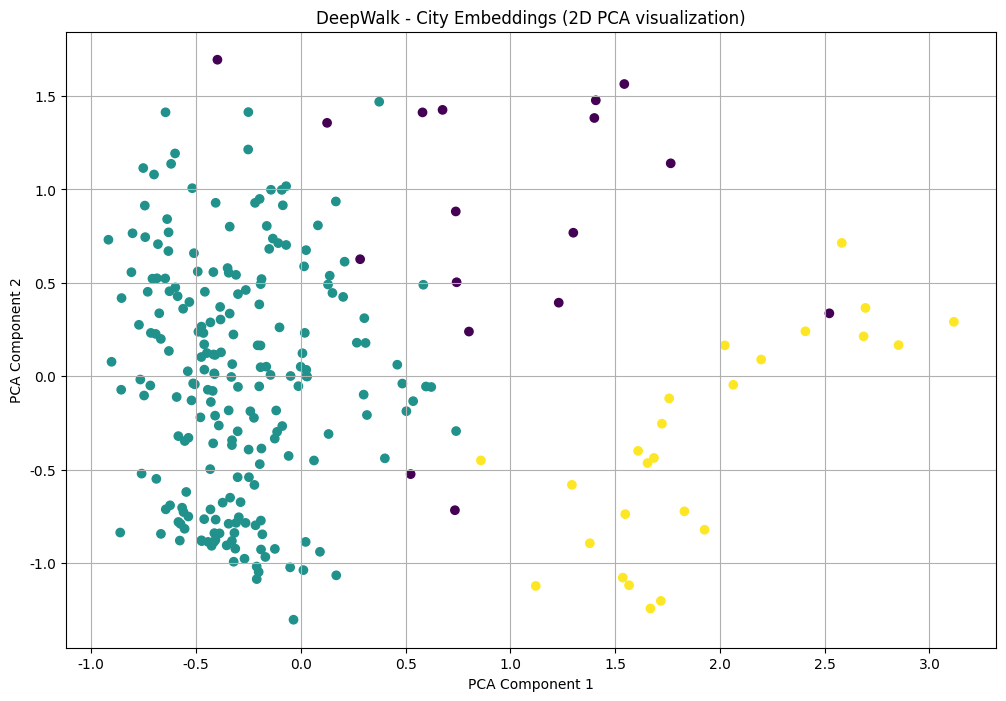

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: KNqX4/Q5Noc=, 相似度: 1.0000001192092896
城市: HexFWXqbb8I=, 相似度: 0.14073948562145233
城市: AKQNtuL5r6Q=, 相似度: 0.1351383477449417
城市: Mv6HkAiSLUk=, 相似度: 0.10737847536802292
城市: n465JzB8Rrw=, 相似度: 0.048964161425828934
城市: N4hmDZN/CJQ=, 相似度: 0.2191077321767807
城市: 5t+HPO9Mu/w=, 相似度: 0.08040269464254379
城市: X5e5r3CS4OA=, 相似度: 0.48955270648002625
城市: EF9aodHSh3E=, 相似度: 0.09175750613212585
城市: iX2Pe2pxiqQ=, 相似度: 0.2459053248167038
城市: lrbLyY7nRiw=, 相似度: 0.5105813145637512
城市: vbo2dwBOeps=, 相似度: 0.21352124214172363
城市: fl/vmiIcdls=, 相似度: 0.3561740219593048
城市: a2cXIUGpIbw=, 相似度: 0.11480804532766342
城市: Ne7JZ9C2ayc=, 相似度: 0.15945063531398773
城市: XUXDuFGVfBM=, 相似度: 0.17737410962581635
城市: tKjndGSl9NQ=, 相似度: 0.04813227429986
城市: xIqe+QQIQXQ=, 相似度: 0.15235280990600586
城市: RTA+2OkM90I=, 相似度: 0.3460743725299835
城市: KETr2NAmAHE=, 相似度: 0.24439984560012817
城市: OJ0BsQ7KlKk=, 相似度: 0.09751199930906296
城市: So/c8CkA/Xs=, 相似度: 0.2669864296913147
城市: Lue5PP9SfQU=, 相似度: 0.21173541247844696
城市: h9GisD/ZayE=, 相似度

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [11]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.46473583579063416


In [10]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../../data-hh/my/encoder/城市嵌入编码_总客流加权图', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

城市嵌入表示已保存。
